In [9]:
!git clone https://github.com/Satwik-1234/BORI-DAM-breach-plots-.git



Cloning into 'BORI-DAM-breach-plots-'...
remote: Enumerating objects: 107, done.
remote: Counting objects: 100% (107/107), done.
remote: Compressing objects: 100% (93/93), done.
remote: Total 107 (delta 31), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (107/107), 1.15 MiB | 9.96 MiB/s, done.
Resolving deltas: 100% (31/31), done.


In [11]:
%cd /content
!ls



/content
BORI-DAM-breach-plots-	Large_Controlled_Release_Hydrograph.xlsx  sample_data


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import plotly.graph_objects as go

# Load Excel
file_path = "Large_Controlled_Release_Hydrograph.xlsx"

df = pd.read_excel(file_path)

# Rename for consistency (optional but recommended)
df.columns = [
    "Index",
    "Time",
    "HW_Elevation",
    "TW_Elevation",
    "Total_Discharge",
    "Remarks"
]

# Convert 'Time' column to string to handle '2400' before conversion
df['Time_str'] = df['Time'].astype(str)

# Identify rows where '2400' is present
mask_2400 = df['Time_str'].str.contains('2400', na=False)

# Replace '2400' with '0000'
df.loc[mask_2400, 'Time_str'] = df.loc[mask_2400, 'Time_str'].str.replace('2400', '0000')

# Convert to datetime
df['Time'] = pd.to_datetime(df['Time_str'], format="%d%b%Y %H%M")

# Add one day to entries that originally had '2400' to represent next day's midnight
df.loc[mask_2400, 'Time'] = df.loc[mask_2400, 'Time'] + pd.Timedelta(days=1)

# Drop the temporary 'Time_str' column
df = df.drop(columns=['Time_str'])

==========================================

# **🔵 MATPLOTLIB – STATIC ENGINEERING GRAPH**

**🟦 OUTPUT 1: HW–TW Elevation + Controlled Release Discharge**

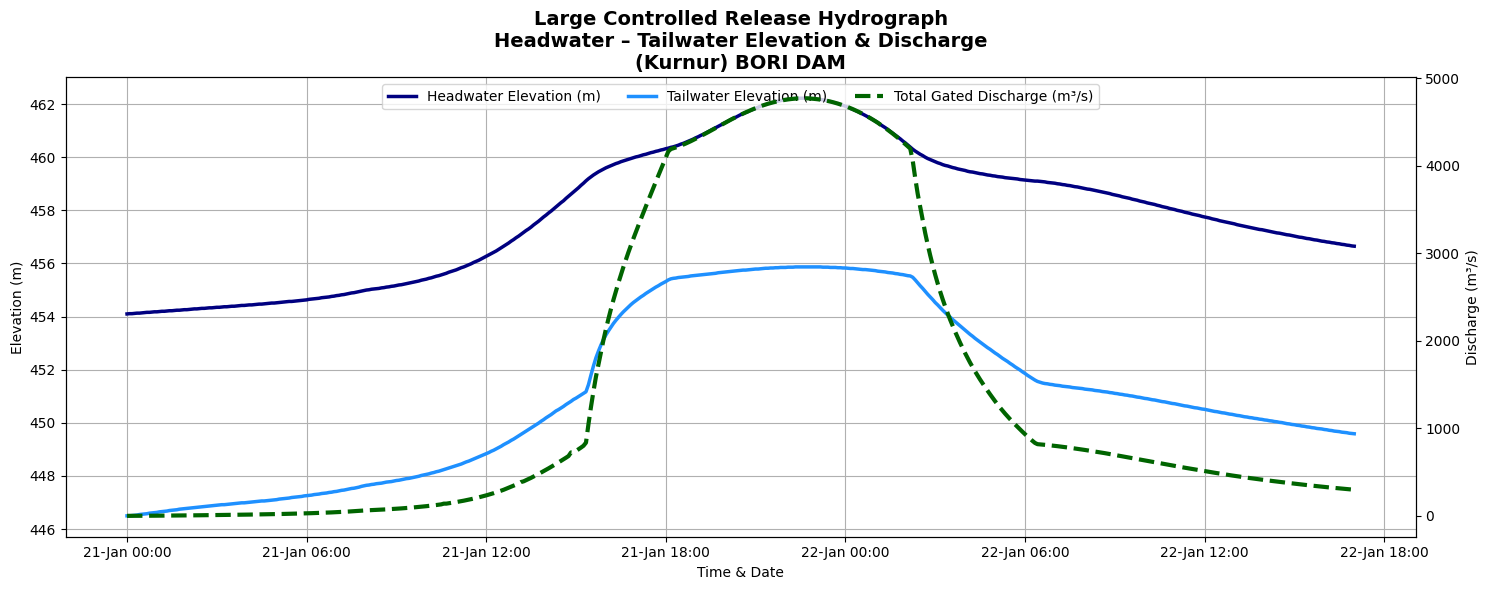

In [ ]:
fig, ax1 = plt.subplots(figsize=(15,6))

# Elevations
ax1.plot(df["Time"], df["HW_Elevation"],
         color="navy", linewidth=2.5,
         label="Headwater Elevation (m)")

ax1.plot(df["Time"], df["TW_Elevation"],
         color="dodgerblue", linewidth=2.5,
         label="Tailwater Elevation (m)")

ax1.set_xlabel("Time & Date")
ax1.set_ylabel("Elevation (m)")
ax1.grid(True)

# Discharge axis
ax2 = ax1.twinx()
ax2.plot(df["Time"], df["Total_Discharge"],
         color="darkgreen", linewidth=3,
         linestyle="--",
         label="Total Gated Discharge (m³/s)")

ax2.set_ylabel("Discharge (m³/s)")

# Title
plt.title(
    "Large Controlled Release Hydrograph\n"
    "Headwater – Tailwater Elevation & Discharge\n"
    "(Kurnur) BORI DAM",
    fontsize=14, fontweight="bold"
)

# One-line combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper center",
    ncol=3,
    frameon=True
)

# Time formatting
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%d-%b %H:%M"))
plt.tight_layout()
plt.show()


==========================================

## **🟠 PLOTLY – INTERACTIVE TECHNICAL GRAPH**


🟧 **OUTPUT 2: Controlled Release Hydrograph (Plotly)**

In [ ]:
fig = go.Figure()

# Headwater
fig.add_trace(go.Scatter(
    x=df["Time"],
    y=df["HW_Elevation"],
    mode="lines",
    line=dict(color="navy", width=3),
    name="Headwater Elevation (m)"
))

# Tailwater
fig.add_trace(go.Scatter(
    x=df["Time"],
    y=df["TW_Elevation"],
    mode="lines",
    line=dict(color="dodgerblue", width=3),
    name="Tailwater Elevation (m)"
))

# Discharge
fig.add_trace(go.Scatter(
    x=df["Time"],
    y=df["Total_Discharge"],
    mode="lines",
    line=dict(color="darkgreen", width=3, dash="dash"),
    name="Total Gated Discharge (m³/s)",
    yaxis="y2"
))

fig.update_layout(
    title=(
        "Large Controlled Release Hydrograph<br>"
        "Headwater – Tailwater Elevation & Discharge<br>"
        "(Kurnur) BORI DAM"
    ),
    xaxis=dict(title="Time & Date"),
    yaxis=dict(title="Elevation (m)"),
    yaxis2=dict(
        title="Discharge (m³/s)",
        overlaying="y",
        side="right"
    ),
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="center",
        x=0.5
    ),
    template="plotly_white"
)

fig.show()
